# Assignment 5: Random Forest Classifier
Charlie Vang

Data Science II

Spring 2025

4/22/25

## Part 1: Setup and Dataset Selection

In [ ]:
# Import all required libraries
import pandas as pd
import numpy as py
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

# Display dataset prescription and preview it
wine = load_wine()
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

## Part 2: Build a Random Forest Classifier

### Spliting the dataset into training and testing sets

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(wine.data, wine.target, test_size=0.2)

### Train a RandomForestClassifier using the training data

In [ ]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train, y_train)

RandomForestClassifier()

### Display the Model's Accuracy, Confusion Matrix, and Classification Report

In [ ]:
# Display the model's accuracy
from sklearn.metrics import accuracy_score
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9722222222222222


In [ ]:
# Display the model's confusion matrix
from sklearn.metrics import confusion_matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matric:
 [[13  0  0]
 [ 0 16  1]
 [ 0  0  6]]


In [ ]:
# Display the model's classification report
from sklearn.metrics import classification_report
print("Classification Report: \n", classification_report(y_test, y_pred))

Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      0.94      0.97        17
           2       0.86      1.00      0.92         6

    accuracy                           0.97        36
   macro avg       0.95      0.98      0.96        36
weighted avg       0.98      0.97      0.97        36



## Part 3: Experimentation and Visualization

### Change the numbers of estimators

In [ ]:
# Retrain
X_train, X_test, y_train, y_test = train_test_split(wine.data, wine.target, test_size=0.2)

# With estimator of 10
clf = RandomForestClassifier(n_estimators=10)
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Estimate with 10 Accuracy: ", accuracy_score(y_test, y_pred))

Estimate with 10 Accuracy:  0.9444444444444444


In [ ]:
# With estimate of 50
clf = RandomForestClassifier(n_estimators=50)
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Estimate with 50 Accuracy: ", accuracy_score(y_test, y_pred))

Estimate with 50 Accuracy:  0.9722222222222222


In [ ]:
# With estimate of 100
clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Estimate with 100 Accuracy: ", accuracy_score(y_test, y_pred))

Estimate with 100 Accuracy:  0.9722222222222222


### Comment on the Accuracy
With the estimator being 10, the accuracy decreased at 0.9444. With 50 and 100 estimators the accuracy was the same at 0.9722. The accuracy with 50 and 100 estimators is similar to the first accuracy which was also at 0.9722.

### Plot feature importances using mathplotlib

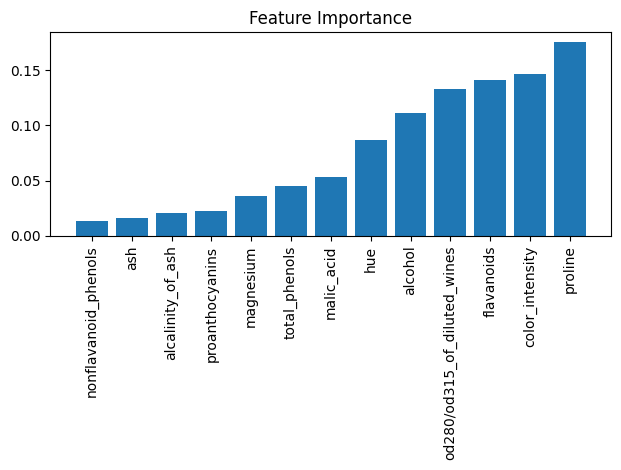

In [ ]:
# Plot feature importance
import numpy as np

importances = clf.feature_importances_
indices = np.argsort(importances)

# Sort the feature importances in descending order
plt.figure()
plt.title("Feature Importance")
plt.bar(range(wine.data.shape[1]), importances[indices], align="center")
plt.xticks(range(wine.data.shape[1]), [wine.feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

## Part 4: Summary and Reflection

One random forests advantage include higher accuracy than decision trees since it will use the averate of multiple trees. Another advantage is hwo the model will estimate feature importance in the model's prediction. When increasing the number of estimators, it did not increase the performance. In fact, it stayed relatively the same with estimators from 50-100. The top 5 most important features are proline, color intensity, flavanoids, diluted ines, and alcohol.